In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
name='79_3.jpg'
_path1 = os.path.join(r'C:\Users\hp\Desktop\tc_data\150x70\blister4x\new1\79\4x', name)
roi_mask = os.path.join(r'C:\Users\hp\Desktop\tc_data\150x70\blister4x\new1\79\4x\roi', '79_3.png')
img = np.array(Image.open(_path1))
mask = np.array(Image.open(roi_mask))
print(img.shape)

(2048, 4384, 3)


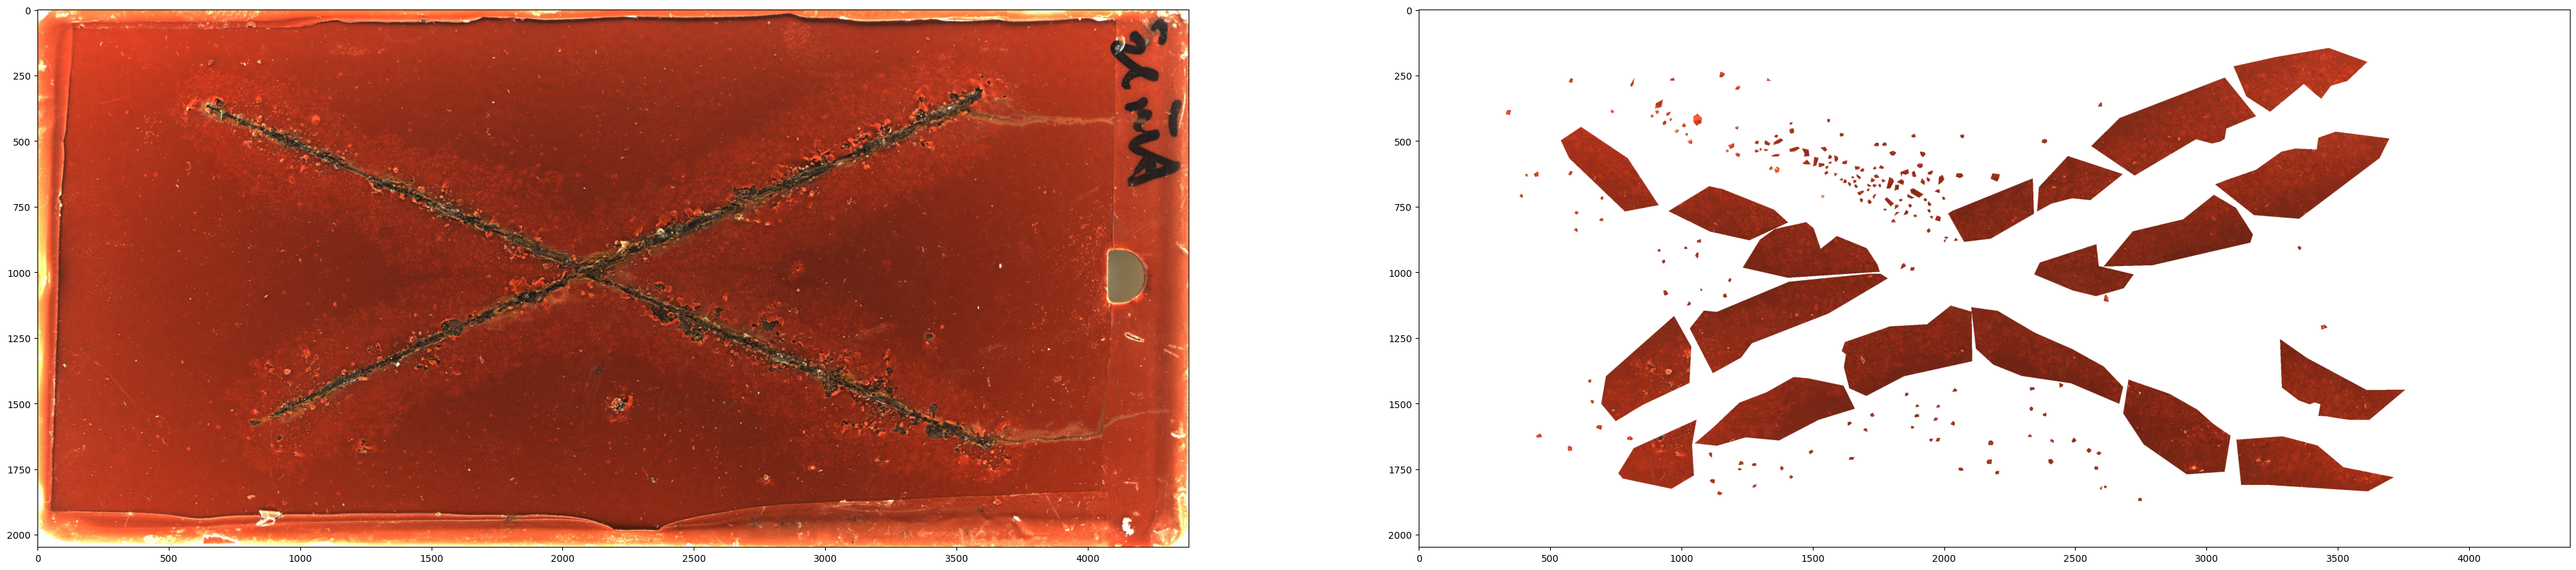

In [3]:
plt.figure(figsize=(48,24))
plt.subplot(1,2,1)
plt.imshow(img)
img_roi = img.copy()
_mask = mask==0
img_roi[_mask] = (255, 255,255)
plt.subplot(1,2,2)
plt.imshow(img_roi)

In [4]:
# 保存图片
_saved_img = Image.fromarray(img_roi)
_saved_img.save(r'C:\Users\hp\Desktop\tc_data\150x70\blister4x\new1\79\4x\ps\3c.jpg')

In [6]:
img_roi = img.copy()
_mask = mask==1
roi = img_roi[_mask]

In [ ]:
# img_roi = img.copy()
# roi = img_roi

In [7]:
data = roi / 255.0 # use 0...1 scale
data = data.reshape(-1, 3)

In [8]:
from sklearn.cluster import MiniBatchKMeans, KMeans
# _kmeans = MiniBatchKMeans(5)
_kmeans = KMeans(n_clusters=5, random_state=0)

_kmeans.fit(data)
# new_colors = _kmeans.cluster_centers_[_kmeans.predict(data)]
pixel_centers = (_kmeans.cluster_centers_*255).astype(np.uint8)
# print(_kmeans.cluster_centers_*255)

In [9]:
s = _kmeans.predict(data)
new_colors = pixel_centers[s]

In [10]:
# img_recolored = new_colors.reshape(img.shape)

img_recolored = np.ones_like(img, dtype=np.uint8)*255
img_recolored[_mask] = new_colors
# img_recolored = (img_recolored*255).astype(np.uint8)

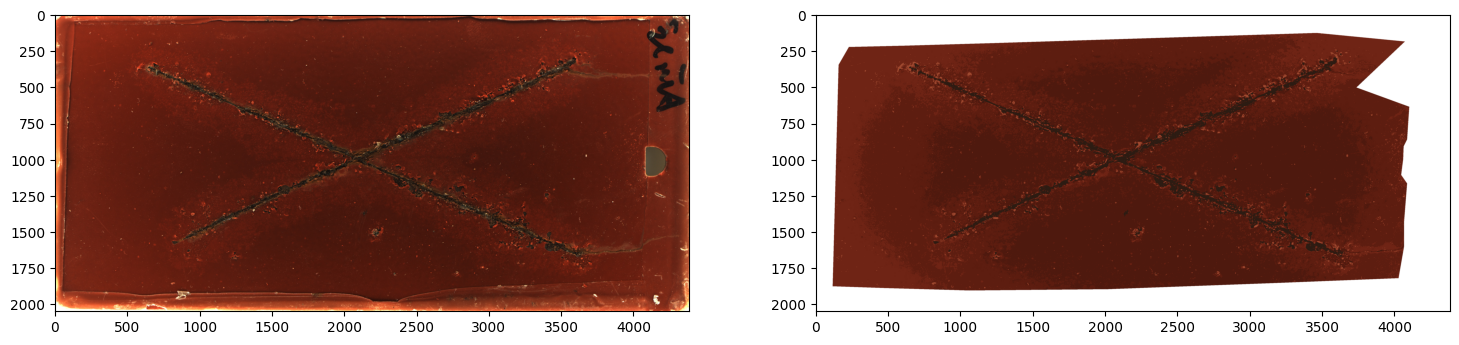

In [11]:
plt.figure(figsize=(18,12))
plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(img_recolored)

In [ ]:
plt.imshow(cv2.cvtColor(img_recolored, cv2.COLOR_RGB2GRAY), cmap='gray')

In [12]:
# 保存图片
_saved_img = Image.fromarray(img_recolored)
_saved_img.save(r'C:\Users\hp\Desktop\tc_data\150x70\blister4x\new1\79\4x\ps\3c.jpg')

In [ ]:
def colorRGB_To_mask(img_recolored, color):
    _mask = np.logical_and(img_recolored[:,:,0]==color[0], img_recolored[:,:,1]==color[1])
    _mask = np.logical_and(_mask, img_recolored[:,:,2]==color[2])
    return _mask
    

In [ ]:
new_mask = np.ones((img_recolored.shape[0], img_recolored.shape[1]), dtype=np.uint8)*255
color0 = pixel_centers[1]
_mask0 = colorRGB_To_mask(img_recolored, color0)
color4 = pixel_centers[4]
_mask4 = colorRGB_To_mask(img_recolored, color4)

# _mask = _mask0
_mask = np.logical_or(_mask0, _mask4)
new_mask[_mask] = 0
plt.imshow(new_mask, cmap='gray')

In [ ]:
float_img = img.astype(np.float32)/255.0

float_img[_mask] = float_img[_mask] + (0,0.5,0)

float_img = np.clip(float_img, 0, 1)
plt.imshow(float_img)

In [ ]:

# 保存图片
_saved_img = Image.fromarray((float_img*255).astype(np.uint8))
_saved_img.save(r'C:\Users\hp\Desktop\1.bmp')